<a href="https://colab.research.google.com/github/Srihari0804/Image-Recognition/blob/main/Digit_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow as tf

In [ ]:
!pip install idx2numpy

Dataset Shape: (60000, 28, 28)


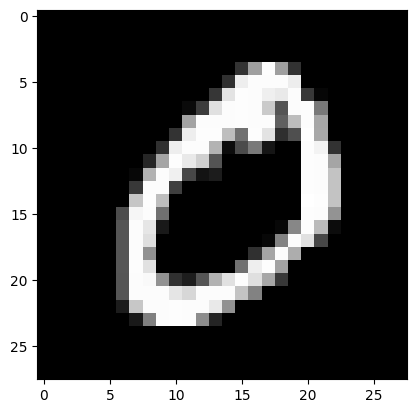

In [ ]:
import idx2numpy
import matplotlib.pyplot as plt

# Replace 'train-images-idx3-ubyte' with your actual filename
file = '/content/train-images.idx3-ubyte'
data = idx2numpy.convert_from_file(file)

# 'data' is now a NumPy array of shape (60000, 28, 28)
print(f"Dataset Shape: {data.shape}")

# Visualize the first image
plt.imshow(data[1], cmap='gray')
plt.show()

In [ ]:
#Convert labels

file = "/content/train-labels.idx1-ubyte"
labels = idx2numpy.convert_from_file(file)

# 'data' is now a NumPy array of shape (60000, 28, 28)
print(f"Dataset Shape: {labels.shape}")
print(labels)

Dataset Shape: (60000,)
[5 0 4 ... 5 6 8]


In [ ]:
#for validation and test
file = "/content/t10k-images.idx3-ubyte"
val_data = idx2numpy.convert_from_file(file)
print(f"Dataset Shape: {val_data.shape}")

normalized_val_data = val_data/255

Dataset Shape: (10000, 28, 28)


In [ ]:
file = "/content/t10k-labels.idx1-ubyte"
val_labels = idx2numpy.convert_from_file(file)

print(f"Dataset Shape: {val_labels.shape}")
print(val_labels)

Dataset Shape: (10000,)
[7 2 1 ... 4 5 6]


In [ ]:
#Splitting val to test and val
from sklearn.model_selection import train_test_split

normalized_val_data,normalized_test_data, val_labels, test_labels  = train_test_split(normalized_val_data,val_labels,test_size=0.5,random_state=42)

In [ ]:
print(data[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

In [ ]:
#Normalize Data /255, Feature scaling
normalized_data = data/255

In [ ]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(tf.keras.layers.MaxPooling2D((2, 2)))
model.add(tf.keras.layers.Conv2D(64, (3, 3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D((2, 2)))
model.add(tf.keras.layers.Conv2D(64, (3, 3), activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(10))

In [ ]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


In [ ]:
print(normalized_test_data.shape)
print(test_labels.shape)

(5000, 28, 28)
(5000,)


In [ ]:
history = model.fit(normalized_data, labels, epochs=3,
                    validation_data=(normalized_val_data, val_labels))

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 32ms/step - accuracy: 0.8964 - loss: 0.3350 - val_accuracy: 0.9858 - val_loss: 0.0402
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 32ms/step - accuracy: 0.9834 - loss: 0.0511 - val_accuracy: 0.9886 - val_loss: 0.0347
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 32ms/step - accuracy: 0.9895 - loss: 0.0330 - val_accuracy: 0.9914 - val_loss: 0.0258


In [ ]:
import matplotlib.pyplot as plt

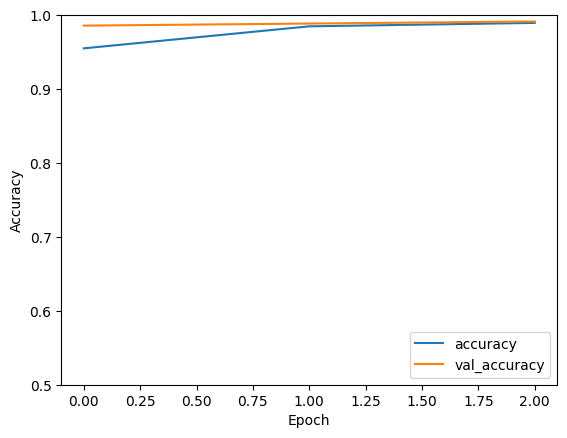

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

In [ ]:
test_loss, test_acc = model.evaluate(normalized_test_data,  test_labels, verbose=2)

157/157 - 1s - 9ms/step - accuracy: 0.9916 - loss: 0.0289


In [ ]:
print(test_acc)

0.991599977016449
